# Lab 3, Task 1: Kernel Functions, K-Means, and RBF Networks

In this lab you will implement kernel functions, the K-means clustering
algorithm, and a radial basis function (RBF) network for binary classification.
In the final task you will combine all the pieces and compare your RBF network
with a support vector machine (SVM) that uses an RBF kernel.

The three tasks form a single pipeline that ends with a working binary
classifier. Each task builds directly on the previous one:

| Task  | File       | What you implement                                          |
| ----- | ---------- | ----------------------------------------------------------- |
| **1** | `subtask1.py` | Four kernel functions (linear, polynomial, RBF, sigmoid)    |
    | **2** | `subtask2.py` | Lloyd's K-means clustering algorithm                        |
| **3** | `subtask3.py` | RBF network classifier + comparison with a scikit-learn SVM |

**Sub Task 1: Kernel functions.** You implement the four standard kernel
functions. The RBF kernel from this task is reused in Sub Task 3 as the
basis function of the RBF network, and is also the kernel chosen for the SVM
you compare against.

**Sub Task 2: K-Means.** You implement Lloyd's algorithm from scratch. K-means
is used in Sub Task 3 to place the RBF network's centres: rather than fixing the
centres by hand, the network learns a set of $K$ representative points from
the training data in an unsupervised way.

**Sub Task 3: RBF network.** You combine the RBF kernel (Sub Task 1) and K-means
(Sub Task 2) to build a complete binary classifier: K-means selects the centres,
the RBF kernel fills the design matrix, and ordinary least squares fits the
weights. You then compare your network with a scikit-learn SVM that uses the
same RBF kernel, exploring how each model's complexity parameters ($K$ and
$\gamma$ for the RBF network; $C$ and $\gamma$ for the SVM) affect accuracy
and the shape of the decision boundary.


All code should be written in Python. You may use NumPy and, where explicitly
stated, scikit-learn.

## Data

Throughout this lab we use a synthetic two-dimensional dataset with binary
labels $y \in \{-1, +1\}$. Run the following code to generate the data:

In [10]:
import numpy as np
import matplotlib.pylab as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=67)
y = 2 * y - 1  # convert {0, 1} -> {-1, +1} (our RBF-network will use the sign to determine the label)

Split the data into a training set (first 200 samples) and a test set
(remaining 100 samples):

In [11]:
X_train, y_train = X[:200], y[:200]
X_test, y_test = X[200:], y[200:]

## Sub Task 1: Kernel functions

A _kernel function_ $k \colon \mathbb{R}^d \times \mathbb{R}^d \to \mathbb{R}$
measures the similarity between two vectors. Formally, a function $k$ is a valid
(positive semi-definite) kernel if there exists a feature map
$\phi \colon \mathbb{R}^d \to \mathcal{H}$ such that

$$
k(\mathbf{x}, \mathbf{x}') = \langle \phi(\mathbf{x}),\, \phi(\mathbf{x}') \rangle.
$$

Kernels let us compute inner products in high-dimensional (even
infinite-dimensional) feature spaces without ever constructing $\phi$ explicitly.
This idea—known as the _kernel trick_—is central to many machine-learning
methods, including support vector machines.

Some commonly used kernels are listed below.

| Kernel | Definition |
| --- | --- |
| **Linear** | $k(\mathbf{x}, \mathbf{x}') = \mathbf{x}^\top \mathbf{x}'$ |
| **Polynomial** | $k(\mathbf{x}, \mathbf{x}') = (\gamma\, \mathbf{x}^\top \mathbf{x}' + c_0)^p$ |
| **RBF (Gaussian)** | $k(\mathbf{x}, \mathbf{x}') = \exp\!\bigl(-\gamma \lVert \mathbf{x} - \mathbf{x}' \rVert^2\bigr)$ |
| **Sigmoid (hyperbolic tangent)** | $k(\mathbf{x}, \mathbf{x}') = \tanh(\gamma\, \mathbf{x}^\top \mathbf{x}' + c_0)$ |

Implement the four kernel functions listed here. Each
function should accept two 2-D arrays `X` of shape `(n, d)` and `Y` of shape
`(m, d)` and return the kernel (Gram) matrix of shape `(n, m)`.


In [12]:
def linear_kernel(X, Y):
    """Compute the linear kernel matrix.

    Parameters
    ----------
    X : ndarray of shape (n, d)
    Y : ndarray of shape (m, d)

    Returns
    -------
    K : ndarray of shape (n, m)
    """
    return X @ Y.T # the linear kernel


def polynomial_kernel(X, Y, gamma=1.0, coef0=1.0, degree=3):
    """Compute the polynomial kernel matrix.

    Parameters
    ----------
    X : ndarray of shape (n, d)
    Y : ndarray of shape (m, d)
    gamma : float
    coef0 : float
    degree : int

    Returns
    -------
    K : ndarray of shape (n, m)
    """
    return (gamma * (X @Y.T)+ coef0) ** degree # the polynomial kernel


def rbf_kernel(X, Y, gamma=1.0):
    """Compute the RBF (Gaussian) kernel matrix.

    Parameters
    ----------
    X : ndarray of shape (n, d)
    Y : ndarray of shape (m, d)
    gamma : float

    Returns
    -------
    K : ndarray of shape (n, m)

    Hint
    ----
    Use the identity ||x - y||^2 = ||x||^2 - 2 x^T y + ||y||^2
    to avoid explicit loops.
    """
    X_square = np.sum(X ** 2, axis=1 , keepdims=True)
    Y_square = np.sum(Y ** 2, axis=1 , keepdims=True).T
    sq_dis = X_square - 2.0 * (X @ Y.T) + Y_square
    return np.exp(-gamma * sq_dis) # the RBF kernel


def sigmoid_kernel(X, Y, gamma=1.0, coef0=0.0):
    """Compute the sigmoid (hyperbolic tangent) kernel matrix.

    Parameters
    ----------
    X : ndarray of shape (n, d)
    Y : ndarray of shape (m, d)
    gamma : float
    coef0 : float

    Returns
    -------
    K : ndarray of shape (n, m)
    """
    return np.tanh(gamma * (X @Y.T)+ coef0) # the sigmoid kernel


You can verify your implementation against `scikit-learn`

In [13]:
from sklearn.metrics.pairwise import rbf_kernel as sklearn_rbf_kernel

K_yours = rbf_kernel(X_train, X_test, gamma=0.5)
K_sklearn = sklearn_rbf_kernel(X_train, X_test, gamma=0.5)
assert np.allclose(K_yours, K_sklearn), "RBF kernel does not match sklearn"
print("RBF kernel OK")

RBF kernel OK


## Sub Task 2: Lloyd's algorithm (K-means)

Lloyd's algorithm is the standard method for solving the K-means clustering
problem. Given $n$ data points $\mathbf{x}_1, \dots, \mathbf{x}_n \in
\mathbb{R}^d$ and a desired number of clusters $K$, the algorithm proceeds as
follows:

1. **Initialise** cluster centres $\boldsymbol{\mu}_1, \dots,
   \boldsymbol{\mu}_K$ (e.g., by choosing $K$ data points at random).
2. **Assign** each point to the nearest centre:
   $$
   c_i = \arg\min_{k \in \{1,\dots,K\}} \lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2.
   $$
3. **Update** each centre to the mean of the points assigned to it:
   $$
   \boldsymbol{\mu}_k = \frac{1}{|C_k|} \sum_{i \in C_k} \mathbf{x}_i,
   \qquad C_k = \{i : c_i = k\}.
   $$
4. **Repeat** steps 2–3 until the assignments no longer change or a maximum
   number of iterations is reached.

The algorithm is guaranteed to converge (the objective decreases
monotonically), but it may converge to a local minimum. The quality of the
solution depends heavily on the initialisation.

**Your task** is to implement Lloyd's algorithm. Your function should return the final cluster
centres and the assignment vector.

In [14]:
def kmeans(X, K, max_iter=100, random_state=None):
    """Run Lloyd's K-means algorithm.

    Parameters
    ----------
    X : ndarray of shape (n, d)
        Data matrix.
    K : int
        Number of clusters.
    max_iter : int
        Maximum number of iterations.
    random_state : int or None
        Seed for reproducibility.

    Returns
    -------
    centres : ndarray of shape (K, d)
        Final cluster centres.
    labels : ndarray of shape (n,)
        Cluster assignment for each point (values in {0, ..., K-1}).
    """
    rng = np.random.default_rng(random_state)

    # Step 1: Initialise centres by picking K random data points
    n = X.shape[0]
    indices = rng.choice(n, size=K, replace=False)
    centres = X[indices].copy()

    labels = np.zeros(n, dtype=int)

    for iteration in range(max_iter):
        # Step 2: Assign each point to the nearest centre
        # Compute squared distances from each point to each centre: (n, K)
        # Using ||x - mu||^2 = ||x||^2 - 2 x^T mu + ||mu||^2
        X_square = np.sum(X ** 2, axis=1 , keepdims=True)
        centres_square = np.sum(centres ** 2, axis=1 , keepdims=True).T
        sqare_dist =X_square -2 *(X @centres.T) + centres_square

        # Assign new labels for each point.
        new_labels = np.argmin(sqare_dist, axis=1)

        # Step 3: Update centres
        for k in range(K):
            # Find the new labels that are label k
            # If any of the samples are labeled as k
            # Construct a new centroid as the mean of those samples
            mask = new_labels==k
            if mask.any():
                centres[k] = X[mask].mean(axis =0)

        # Step 4: Check for convergence and stop the algorithm 
        # if the new labels are unchanged
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels

    return centres, labels


Verify your implementation by comparing your result with that of `scikit-learn`

Cluster sizes: [28 41 37 41 53]


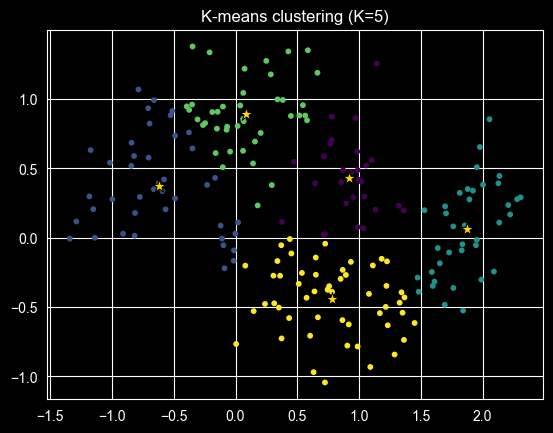

In [15]:
from sklearn.cluster import KMeans

centres, labels = kmeans(X_train, K=5, random_state=420)
print("Cluster sizes:", np.bincount(labels))
import matplotlib.pyplot as plt

plt.scatter(X_train[:, 0], X_train[:, 1], c=labels, cmap="viridis", s=10)
plt.scatter(centres[:, 0], centres[:, 1], c="gold", marker="*", edgecolors="k", linewidths=0.8, s=100)
plt.title("K-means clustering (K=5)")
plt.show()

## Sub Task 3: RBF networks

A radial basis function (RBF) network for binary classification computes

$$
f(\mathbf{x}) = \operatorname{sign}\!\left(\sum_{k=1}^{K} w_k \exp\!\bigl(-\gamma \lVert \mathbf{x} - \boldsymbol{\mu}_k \rVert^2\bigr) + b\right),
$$

where $\boldsymbol{\mu}_1, \dots, \boldsymbol{\mu}_K$ are the _centres_ (or
basis functions), $w_1, \dots, w_K$ are learned weights, and $b$ is a bias
term. Training an RBF network involves two stages:

1. **Select centres** — use an unsupervised method (e.g., K-means) to choose
   $K$ representative centres from the training data.
2. **Fit weights** — construct the design matrix
   $\boldsymbol{\Phi} \in \mathbb{R}^{n \times (K+1)}$ where
   $$
   \Phi_{ik} = \exp\!\bigl(-\gamma \lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2\bigr), \qquad \Phi_{i,K+1} = 1,
   $$
   and solve for the weight vector
   $\mathbf{w} = [w_1, \dots, w_K, b]^\top$ using the pseudo-inverse:
   $$
   \mathbf{w} = \boldsymbol{\Phi}^{+}\, \mathbf{y},
   $$
   where $\mathbf{y} \in \{-1, +1\}^n$ is the vector of labels and
   $\boldsymbol{\Phi}^{+} = (\boldsymbol{\Phi}^\top \boldsymbol{\Phi})^{-1}
   \boldsymbol{\Phi}^\top$ is the Moore–Penrose pseudo-inverse.

Notice that step 2 is exactly the same least-squares problem you solved in
Lab 2 when fitting a linear regression model: the only difference is the
design matrix. In ordinary linear regression the columns of
$\boldsymbol{\Phi}$ are the original features (plus a column of ones for the
intercept). Here, we replace those columns with RBF kernel evaluations
$\exp(-\gamma\lVert \mathbf{x}_i - \boldsymbol{\mu}_k \rVert^2)$, effectively
projecting each data point into a new feature space defined by its similarity
to the $K$ centres. The weight-fitting step itself, i.e., computing
$\mathbf{w} = \boldsymbol{\Phi}^{+}\mathbf{y}$ via the pseudo-inverse is
identical. In other words, an RBF network is a linear model on top of
non-linear RBF features.

**Your task** is to combine the RBF kernel from Sub task 1 and K-means from Sub task 2 to
build an RBF network for binary classification (and finally compare it with an SVM
using the RBF kernel).

In [16]:
class RBFNetwork:
    """RBF network for binary classification.
    
    Parameters
    ----------
    n_centres : int
        Number of RBF centres (K).
    gamma : float
        Width parameter for the Gaussian basis functions.
    random_state : int or None
        Random seed for K-means initialisation.
    """
    
    def __init__(self, n_centres=10, gamma=1.0, random_state=None):
        self.n_centres = n_centres
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y):
        """Fit the RBF network.
    
        1. Run K-means on X to find the centres.
        2. Build the design matrix Phi using the RBF kernel.
        3. Solve for the weights using the pseudo-inverse.
    
        Parameters
        ----------
        X : ndarray of shape (n, d)
        y : ndarray of shape (n,), values in {-1, +1}
        """
        # Step 1: Find centres with K-means (use your implementation)
        # Hint: store the centers. By convention scikit-learn uses self.variable_name_
        # for estimator state. The tests expect the centroids to be self.centers_.
        self.centres_, _ = kmeans(X, self.n_centres, random_state=self.random_state)

    
        # Step 2: Build design matrix Phi of shape (n, K+1)
        #   - First K columns: RBF kernel values between X and the centres
        #   - Last column: ones (bias term)
        # Hint: Use np.hstack (or the more general np.concatenate) to add a column
        # to the matrix.
        Phi= np.hstack ([
            rbf_kernel(X, self.centres_ , gamma = self.gamma ),
            np.ones((X.shape[0], 1))
        ])

    
        # Step 3: Compute weights via pseudo-inverse
        # Hint: you need to store the weight matrix as an instance variable.
        # The tests expect this variable to be self.weights_


        # By convention scikit-learn returns self. This allows for chaining invokations.
        # Example: y_hat = RBFNetwork().fit(X, y).predict(new_X)
        self.weights_ = np.linalg.pinv(Phi) @ y
        return self
    
    def decision_function(self, X):
        """Compute the raw output (before sign) for each sample.
    
        Parameters
        ----------
        X : ndarray of shape (n, d)
    
        Returns
        -------
        scores : ndarray of shape (n,)
        """
        # Step 1: Build the design matrix Phi of shape (n, K+1)
        # using the already fitted centers.
        # Hint: Remember to set the same hyper-parameters for the RBF-kernel.
        # Hint: Remember to construct the design matrix to mirror the the one
        # used during fitting. 
        #   - First K columns: the kernel values
        #   - Last column: ones (the bias term)
        Phi = np.hstack([
        rbf_kernel(X, self.centres_, gamma=self.gamma),
        np.ones((X.shape[0], 1))])

        # Step 3: Return the raw scores (n, ). Positive scores predict +1, negative scores -1
        # The predict function uses these scores and turn them into labels.
        return Phi@self.weights_
    
    def predict(self, X):
        """Predict class labels in {-1, +1}.
    
        Parameters
        ----------
        X : ndarray of shape (n, d)
    
        Returns
        -------
        y_pred : ndarray of shape (n,)
        """
        # We turn the raw scores into a prediction
        return np.sign(self.decision_function(X))


The first step is to `fit` your RBF-network implementation and evaluate accuracy on the test set:

In [17]:
rbf_net = RBFNetwork(n_centres=20, gamma=5.0, random_state=69)
rbf_net.fit(X_train, y_train)

y_pred_rbf = rbf_net.predict(X_test)
acc_rbf = np.mean(y_pred_rbf == y_test)
print(f"RBF network accuracy: {acc_rbf:.2%}")

RBF network accuracy: 96.00%


Now to compare, we fit a support vector machine with the same `gamma`

In [18]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", gamma=5.0, C=1.0)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
acc_svm = np.mean(y_pred_svm == y_test)
print(f"SVM (RBF kernel) accuracy: {acc_svm:.2%}")

SVM (RBF kernel) accuracy: 94.00%


To get a better "feel" for the difference between the two approaches you can plot the decision boundary of each

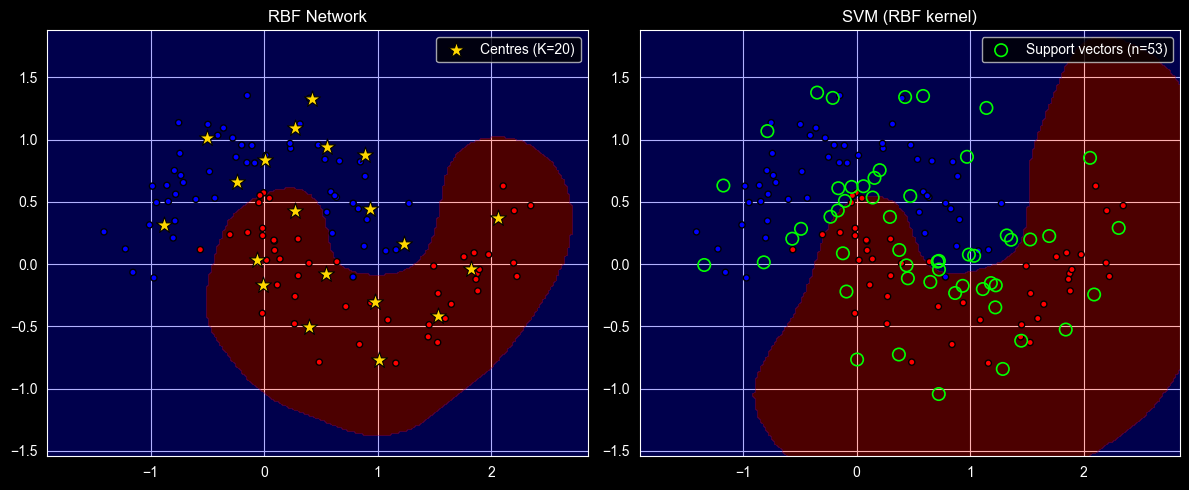

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in zip(
    axes, [rbf_net, svm], ["RBF Network", "SVM (RBF kernel)"]
):
    # Create a grid
    xx, yy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
        np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], alpha=0.3, colors=["blue", "red"])
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="bwr", edgecolors="k", s=20)

    # Highlight the key points for each model
    if isinstance(model, RBFNetwork):
        # Draw the K-means centres used by the RBF network
        ax.scatter(
            model.centres_[:, 0], model.centres_[:, 1],
            c="gold", marker="*", s=150, edgecolors="k", linewidths=0.8,
            zorder=5, label=f"Centres (K={model.n_centres})",
        )
        ax.legend(loc="upper right")
    elif isinstance(model, SVC):
        # Circle the support vectors chosen by the SVM
        sv = model.support_vectors_
        ax.scatter(
            sv[:, 0], sv[:, 1],
            facecolors="none", edgecolors="lime", s=80, linewidths=1.2,
            zorder=5, label=f"Support vectors (n={len(sv)})",
        )
        ax.legend(loc="upper right")

    ax.set_title(title)

plt.tight_layout()
plt.show()

# Reflections
These reflections are not submitted instead they are here to help you build
intuition. Run the code, look at the output, and think about why you see what
you see. Use the hints to point you toward understanding.

## How does the number of centres $K$ affect the RBF network? 

Try $K \in \{2, 5, 10, 20, 50, 100\}$, compute training and test accuracy and reflect.

Note that a very small $K$ means the network has few basis functions and
cannot capture a complex boundary (underfitting). A very large $K$
(close to $n$) gives the network so much flexibility that it fits the
training data almost perfectly but may generalise poorly (overfitting). 
Look for the value of $K$ where test accuracy peaks.

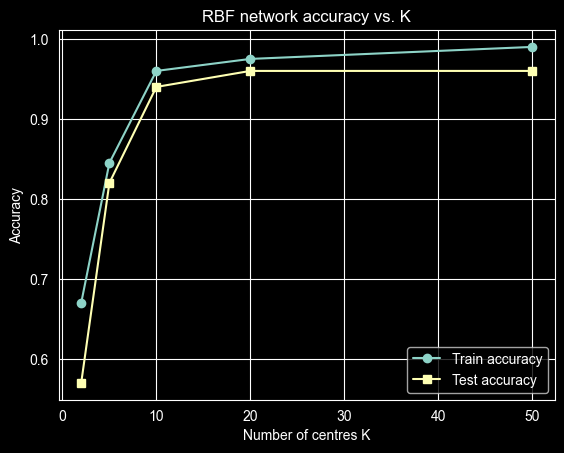

K=  2  train=67.00%  test=57.00%
K=  5  train=84.50%  test=82.00%
K= 10  train=96.00%  test=94.00%
K= 20  train=97.50%  test=96.00%
K= 50  train=99.00%  test=96.00%


In [28]:
K_values = [2, 5, 10, 20, 50]
train_accs, test_accs = [], []

for K in K_values:
   net = RBFNetwork(n_centres=K, gamma=5.0, random_state=67)
   net.fit(X_train, y_train)
   train_accs.append(np.mean(net.predict(X_train) == y_train))
   test_accs.append(np.mean(net.predict(X_test) == y_test))

plt.figure()
plt.plot(K_values, train_accs, marker="o", label="Train accuracy")
plt.plot(K_values, test_accs,  marker="s", label="Test accuracy")
plt.xlabel("Number of centres K")
plt.ylabel("Accuracy")
plt.title("RBF network accuracy vs. K")
plt.legend()
plt.show()

for K, tr, te in zip(K_values, train_accs, test_accs):
   print(f"K={K:>3}  train={tr:.2%}  test={te:.2%}")

## How does the parameter $\gamma$ influence the decision boundary of the RBF network? 

What happens when $\gamma$ is very small or very large?

Recall that each basis function is $\phi(x) = \exp(-\gamma
\|x - c\|^2)$. A small $\gamma$ makes each Gaussian very wide, so every
centre has a broad, smooth influence, i.e., the boundary becomes smooth but may
underfit. A large $\gamma$ shrinks each Gaussian to a narrow spike, so a
centre only "fires" for points very close to it and the boundary becomes
highly localised and can overfit. This is the same $\gamma$ as in the SVM's
RBF kernel.

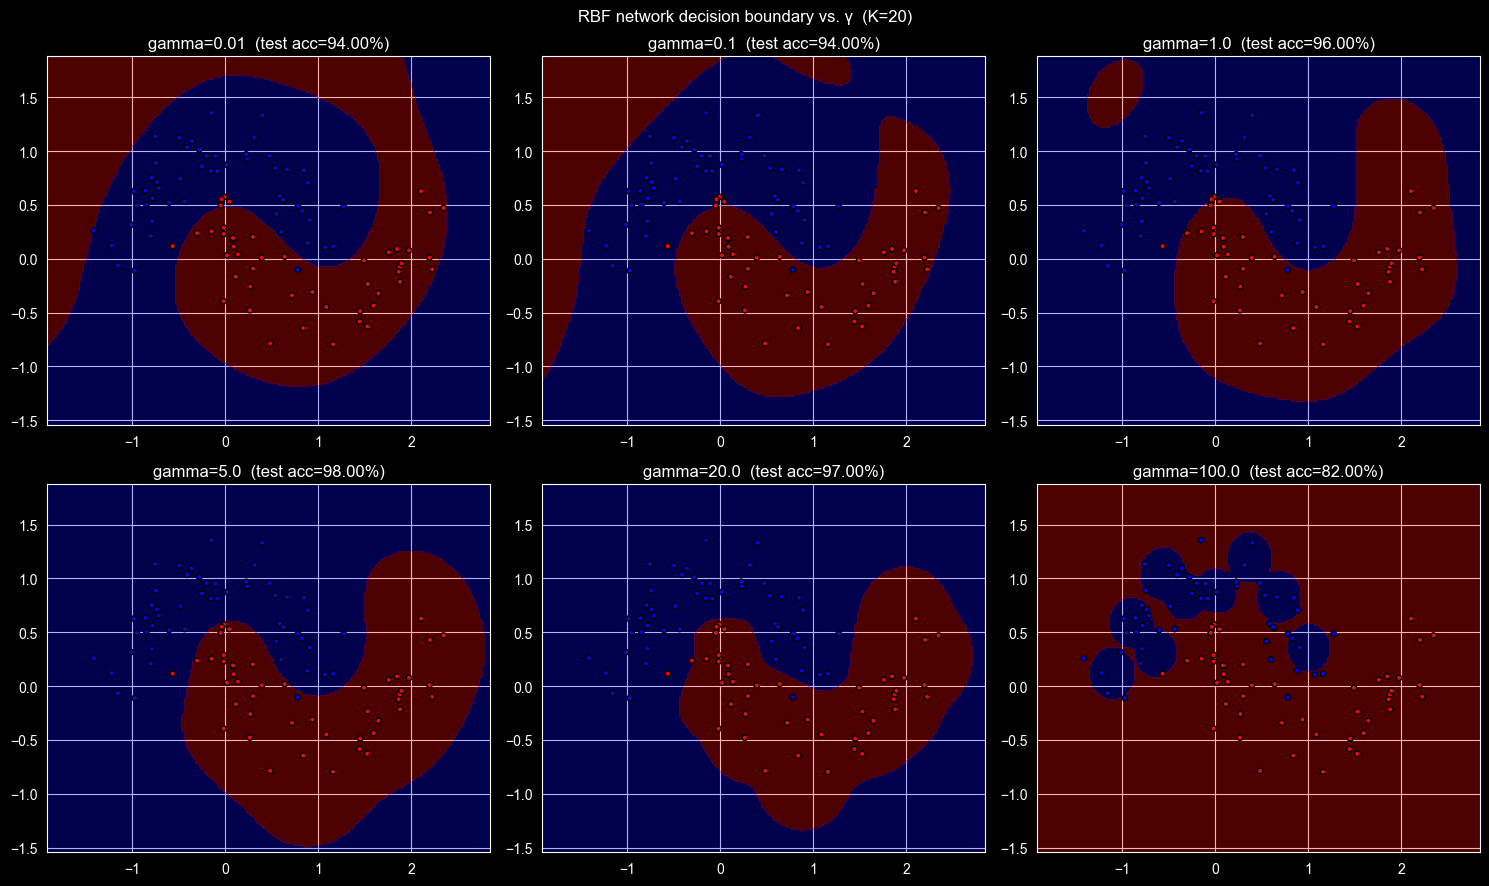

In [29]:
gamma_values = [0.01, 0.1, 1.0, 5.0, 20.0, 100.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

xx, yy = np.meshgrid(
   np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
   np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200),
)
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, gamma in zip(axes.ravel(), gamma_values):
   net = RBFNetwork(n_centres=20, gamma=gamma, random_state=42)
   net.fit(X_train, y_train)
   Z = net.predict(grid).reshape(xx.shape)
   acc = np.mean(net.predict(X_test) == y_test)

   ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], alpha=0.3, colors=["blue", "red"])
   ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="bwr", edgecolors="k", s=15)
   ax.set_title(f"gamma={gamma}  (test acc={acc:.2%})")

plt.suptitle("RBF network decision boundary vs. γ  (K=20)")
plt.tight_layout()
plt.show()


## Compare the RBF network and the SVM with RBF kernel
1. Which model achieves higher test accuracy, and by how much?

2. Does one produce a smoother or more complex boundary than the other? Look at the visualisation.

Note that The SVM's margin-maximisation criterion tends to produce
smoother, more regular boundaries than the least-squares fit of the RBF
network, especially when the number of centres $K$ is large.

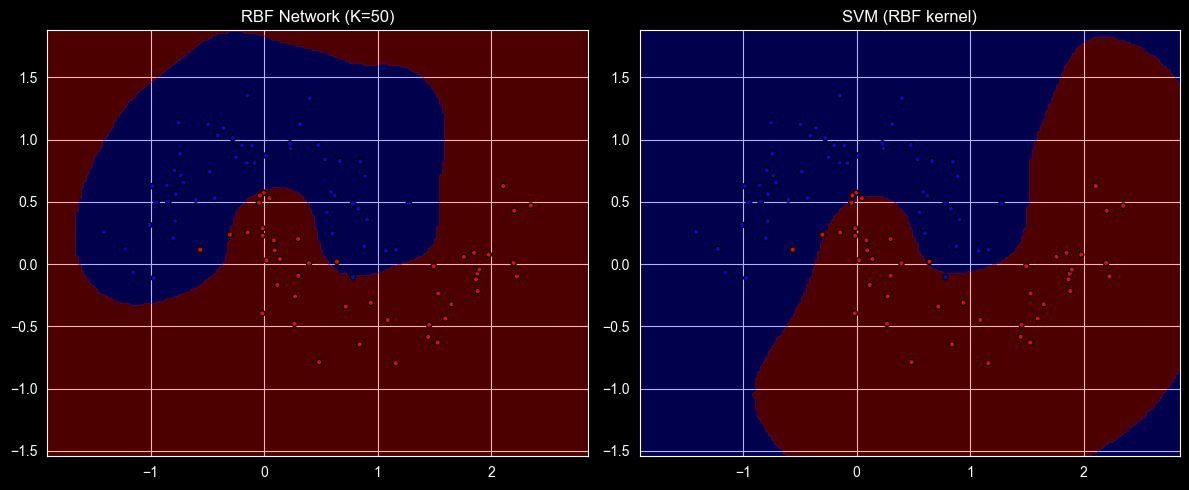

In [30]:
net_large_K = RBFNetwork(n_centres=50, gamma=5.0, random_state=42)
net_large_K.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes, [net_large_K, svm], ["RBF Network (K=50)", "SVM (RBF kernel)"]):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], alpha=0.3, colors=["blue", "red"])
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="bwr", edgecolors="k", s=15)
    ax.set_title(title)
plt.tight_layout()

3. the RBF network always uses exactly $K$ centres; print `len(svm.support_vectors_)` and compare that number to $K$. Is the SVM more or less "compact"?

Note that for a well-tuned SVM the number of support vectors is often
much smaller than $K$. A model is "compact" when it needs fewer stored
exemplars to define its decision function.

## SVM regularisation

Investigate how the SVM's regularisation parameter $C$ affects the number of support vectors and the decision boundary

1. Train SVMs with $C \in \{0.01, 0.1, 1, 10, 100\}$ (keep `gamma=5.0`) and print the number of support vectors for each value.

In [31]:
C_values = [0.01, 0.1, 1, 10, 100]
sv_counts, c_test_accs = [], []

for C in C_values:
    m = SVC(kernel="rbf", gamma=5.0, C=C)
    m.fit(X_train, y_train)
    sv_counts.append(m.support_vectors_.shape[0])
    c_test_accs.append(np.mean(m.predict(X_test) == y_test))
    print(f"C={C:>6}  support vectors={sv_counts[-1]:>4}  test acc={c_test_accs[-1]:.2%}")

C=  0.01  support vectors= 195  test acc=47.00%
C=   0.1  support vectors= 144  test acc=93.00%
C=     1  support vectors=  53  test acc=94.00%
C=    10  support vectors=  35  test acc=97.00%
C=   100  support vectors=  26  test acc=97.00%


2. What happens to the number of support vectors as $C$ increases? Why?

Note that $C$ controls how much the SVM tolerates margin violations.
A small $C$ allows many points to sit inside or on the wrong side of the
margin (soft margin). These points become support vectors. A large $C$
forces the margin to accommodate nearly all training points correctly,
which typically requires fewer, more carefully placed support vectors.

In [ ]:
plt.figure()
plt.semilogx(C_values, sv_counts, marker="o")
plt.xlabel("C  (log scale)")
plt.ylabel("Number of support vectors")
plt.title("SVM: support vector count vs. C  (γ=5.0)")

3. A large $C$ penalises misclassifications heavily. Does this lead to more or fewer support vectors, and does the boundary become simpler or more complex?

With very large $C$ the SVM tries hard to classify every
training point correctly, which can make the boundary highly irregular
(overfitting). With very small $C$ the boundary is smooth but may
misclassify many points (underfitting). The "right" $C$ is somewhere in between.

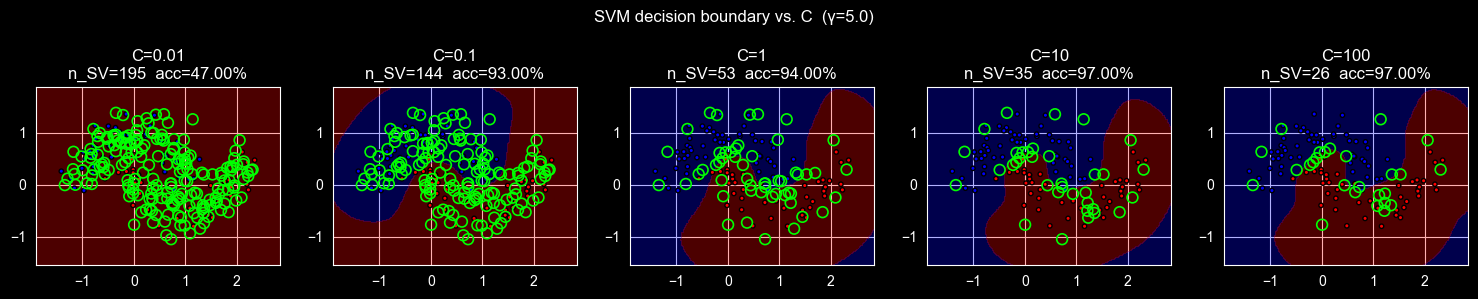

In [32]:
 fig, axes = plt.subplots(1, len(C_values), figsize=(15, 3))

 for ax, C in zip(axes, C_values):
     m = SVC(kernel="rbf", gamma=5.0, C=C)
     m.fit(X_train, y_train)
     Z = m.predict(grid).reshape(xx.shape)
     acc = np.mean(m.predict(X_test) == y_test)

     ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], alpha=0.3, colors=["blue", "red"])
     ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="bwr", edgecolors="k", s=10)
     sv = m.support_vectors_
     ax.scatter(sv[:, 0], sv[:, 1], facecolors="none", edgecolors="lime",
                s=60, linewidths=1.2, zorder=5)
     ax.set_title(f"C={C}\nn_SV={sv.shape[0]}  acc={acc:.2%}")

 plt.suptitle("SVM decision boundary vs. C  (γ=5.0)")
 plt.tight_layout()

4. How does this compare to controlling model complexity in the RBF network (where you vary $K$ instead)?

Both $C$ (SVM) and $K$ (RBF network) act as complexity regularizers. 
$K$ changes the number and placement of basis functions, and $C$ reshapes 
the optimisation objective without changing the number of basis functions explicitly.

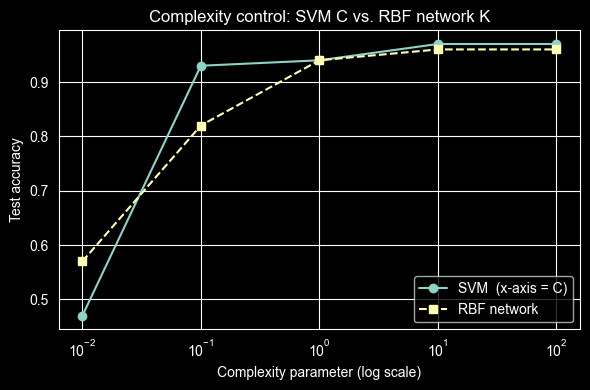

In [33]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.semilogx(C_values, c_test_accs, marker="o", label="SVM  (x-axis = C)")

# We use the C_values for RBF. They are not meaningful but map to K -> growing
ax.semilogx(C_values, test_accs, marker="s", linestyle="--",
            label="RBF network")

ax.set_xlabel("Complexity parameter (log scale)")
ax.set_ylabel("Test accuracy")
ax.set_title("Complexity control: SVM C vs. RBF network K")
ax.legend()
plt.tight_layout()
plt.show()

## Decision function and margin

The RBF network selects its centres using K-means (unsupervised), while the
SVM selects support vectors during training (supervised). What are the advantages and disadvantages of each strategy? 

1. Does the placement of K-means centres depend on the class labels? What
could go wrong if the clusters do not align with the decision boundary?

Note that K-means only looks at the geometry of $X$ and is completely
unaware of $y$. If one class forms multiple tight clusters but they all
lie in the same region of the feature space, K-means may place several
centres far from the decision boundary, wasting capacity that could be used elsewhere.

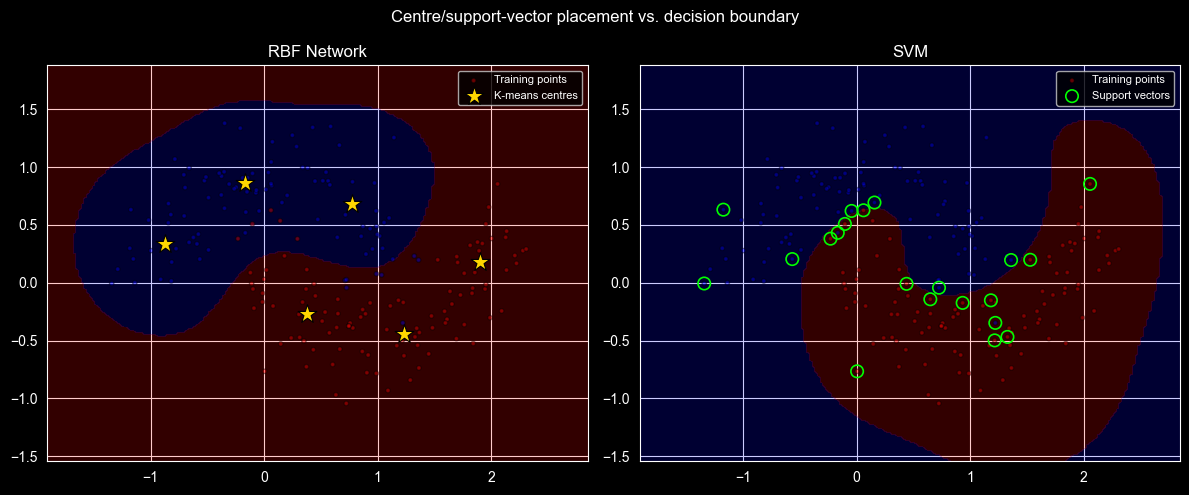

In [34]:
# Visualise where K-means centres land relative to the class boundary.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in zip(axes, [RBFNetwork(n_centres=6, gamma=3).fit(X_train, y_train), SVC(gamma=3, C=100).fit(X_train, y_train)], ["RBF Network", "SVM"]):
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1.5, 0, 1.5], alpha=0.2, colors=["blue", "red"])
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="bwr",
               edgecolors="k", s=10, alpha=0.4, label="Training points")
    if isinstance(model, RBFNetwork):
        ax.scatter(model.centres_[:, 0], model.centres_[:, 1],
                   c="gold", marker="*", s=200, edgecolors="k",
                   linewidths=0.8, zorder=5, label="K-means centres")
    else:
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], facecolors="none", edgecolors="lime",
                   s=80, linewidths=1.2, zorder=5, label="Support vectors")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle("Centre/support-vector placement vs. decision boundary")
plt.tight_layout()

2. Support vectors lie exactly on or near the margin. Why does this make them a more "targeted" set of basis points than K-means centres?

Note that the SVM decision function is scaled so that the margin
boundaries sit at $f(x) = +1$ and $f(x) = -1$. Support vectors are
exactly the training points that fall on or inside those boundaries, so
`|decision_function(support_vectors_)|`  is typically `<= 1` and hard support vectors
cluster right at 1. Points deep inside a class (far from the boundary)
have `|f(x)| >> 1` and play no role in defining the margin at all.
K-means centres are placed to minimise reconstruction error across the
whole input space meaning that they often land in the "easy" interior of a class
where there is little discriminative information, which is why the RBF
centre histogram is spread across much larger values while the SVM
histogram peaks near 1.

We can plot how far from the decision boundary each point and compare their distribution. Play with `n_centers` and `C`. How do they influence the distance to margin?


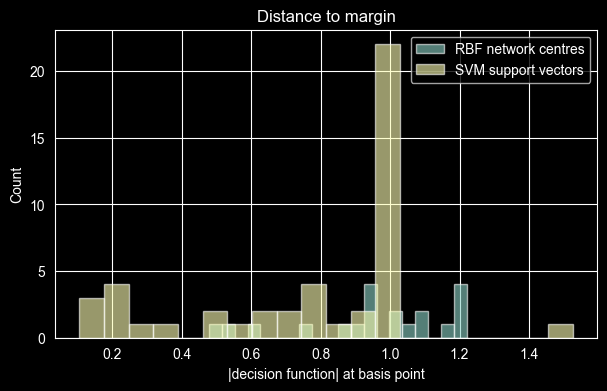

RBF centres  — mean |score|: 0.965
SVM SVs      — mean |score|: 0.772


In [35]:
rbf_net = RBFNetwork(n_centres=20, gamma=3).fit(X_train, y_train)
svm = SVC(gamma=3, C=1).fit(X_train, y_train)
rbf_distances = np.abs(rbf_net.decision_function(rbf_net.centres_))
svm_distances = np.abs(svm.decision_function(svm.support_vectors_))

plt.figure(figsize=(7, 4))
plt.hist(rbf_distances, bins=20, alpha=0.6, label="RBF network centres")
plt.hist(svm_distances, bins=20, alpha=0.6, label="SVM support vectors")
plt.xlabel("|decision function| at basis point")
plt.ylabel("Count")
plt.title("Distance to margin")
plt.legend()
plt.show()

print(f"RBF centres  — mean |score|: {rbf_distances.mean():.3f}")
print(f"SVM SVs      — mean |score|: {svm_distances.mean():.3f}")